## Using YiChao's HI generation code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import sys
sys.path.append('/anaconda2/lib/python2.7/site-packages/cora-3.0.0+22.g596b45d-py2.7-linux-x86_64.egg')
print('I need to apend cora to my path for some reason even when using the HI_IM-PY2 kernel')
from meerKAT_sim.sim import cube_sim
from meerKAT_utils import algebra as al
from meerKAT_sim.pipeline.pipeline import run_pipeline
print('This requires many scripts in meerKAT_sim/sim so you need to have correctly installed YiChaos sims in Python2')

I need to apend cora to my path for some reason even when using the HI_IM-PY2 kernel
This requires many scripts in meerKAT_sim/sim so you need to have correctly installed YiChaos sims in Python2


In [2]:
#first we make a H1 cube and save to file

num_ch = 250 #how many frequency channels you want 
spac = 0.2 #spacing between your frequency channels in MHz
freq_range = np.linspace(971.2, num_ch*spac+971.2, num_ch) #gives 971.2 to 1021.2 MHz 
mock_num = 20 #how many Universes do you want to make

@run_pipeline
def sim_cube():
    
    pipe_tasks = []
    pipe_outdir = 'h1cube' #name of file and path - unchanged it will create new directory inside current directory 
    pipe_logging = 'info'
    pipe_feedback = 2
    pipe_copy = False

    pipe_tasks.append(cube_sim.CubeSim)

    csim_prefix           = 'MeerKAT64_wiggleZ11hr'
    nch = num_ch
    csim_freq             = freq_range
    csim_mock_n           = mock_num
    csim_scenario         = 'ideal' #three choices for this which I don't understand, check cube_sim.py if you are a HI expert
    csim_refinement       = 1
    csim_field_centre     = (162.5, 3.5) #RA and dec

    csim_pixel_spacing    = 0.2
    csim_map_shape        = [200, 60]
    csim_map_pad          = 5

    csim_outfiles = ['raw', 'delta', 'withbeam'] # code currently applies Gaussia MeerKAT beam
    
    return locals()

#sim_cube() #YOU NEED TO UNCOMMENT THIS THE FIRST TIME YOU RUN (then recomment)

In [4]:
#Now read in HI cube
hi_model_type = 'withbeam' # we want the HI convolved with the beam
hi_bias = 1.0 #no HI bias

with h5py.File('h1cube/MeerKAT64_wiggleZ11hr_cube_ideal.h5', 'r') as fhi:
    hi_model = al.load_h5(fhi, hi_model_type)
    print 'HI bias %3.2f'%hi_bias
    hi_model *= hi_bias 
    mock_n = min(hi_model.shape[0], mock_num) #we can choose to make 1000 mocks but only look at 20 of them for instance
    hi_model = hi_model[:mock_num]
    hi_model = al.make_vect(hi_model)
    freq = hi_model.get_axis('freq')
    print 'Using freq from HI model, freq [st=%f, ed=%f, N=%d]'%\
                    (freq[0], freq[-1], freq.shape[0])

HI bias 1.00
Using freq from HI model, freq [st=971.200000, ed=1021.200000, N=250]


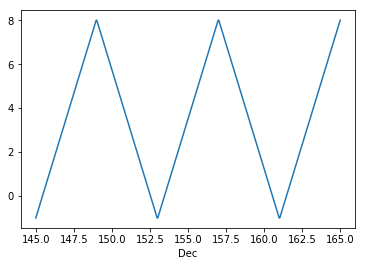

(20, 500, 250, 1)
N_mocks by Ntod by NFreq


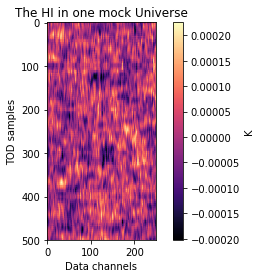

In [16]:
#input RA and DEC that we want to see the HI for
ra_list = np.linspace(145, 165, 500)
dec_list = np.hstack((np.linspace(-1, 8, 100), np.linspace(8, -1, 100), np.linspace(-1, 8, 100), \
                         np.linspace(8, -1, 100), np.linspace(-1, 8, 100)))
plt.plot(ra_list, dec_list)
plt.xlabel('R.A')
plt.xlabel('Dec')
plt.show()

#extract ra and dec that we are intersted in from our cube simulation  
hi_model_ra  = hi_model.get_axis('ra')
hi_model_dec = hi_model.get_axis('dec')
_hi = np.rollaxis(hi_model, 1, 4)

ra_idx  = np.argmin(np.abs(ra_list[:,None]  - hi_model_ra[None, :]), axis=1)
dec_idx = np.argmin(np.abs(dec_list[:,None] - hi_model_dec[None, :]), axis=1)
                
wanted_hi = _hi[:, list(ra_idx), list(dec_idx), :, None]
print(np.shape(wanted_hi))
print('N_mocks by Ntod by NFreq')

plt.imshow(wanted_hi[0,:,:,0], cmap='magma')
plt.xlabel('Data channels')
plt.ylabel('TOD samples')
cbar = plt.colorbar()
cbar.set_label('K')
plt.title('The HI in one mock Universe')
plt.show()